<a href="https://colab.research.google.com/github/vikassinngh123/AI-ML-Learning/blob/main/Machine-Learning/California_Housing_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("camnugent/california-housing-prices")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'california-housing-prices' dataset.
Path to dataset files: /kaggle/input/california-housing-prices


In [3]:
cali_df=pd.read_csv(path+'/housing.csv')
cali_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
cali_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
# Only total_bedroom has null value
cali_df.dropna(inplace=True)

cali_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
graph_lo_df=px.scatter(cali_df,
                          x='longitude',
                          y='median_house_value',
                          opacity=0.8,
                          color='ocean_proximity',
                          hover_data=['ocean_proximity']
                          )
graph_lo_df.show()

In [7]:
cali_df.longitude.corr(cali_df.median_house_value)

np.float64(-0.04539821933444485)

In [8]:
cali_df.longitude.corr(cali_df.latitude)

np.float64(-0.9246161131160101)

In [9]:
cali_df.median_income.corr(cali_df.median_house_value)

np.float64(0.6883554753161123)

In [10]:
graph_lo_df=px.scatter(cali_df,
                          x='median_income',
                          y='median_house_value',
                          opacity=0.8,
                          color='ocean_proximity',
                          hover_data=['ocean_proximity']
                          )
graph_lo_df.show()

#### Heatmap for correlation between diffirent cols

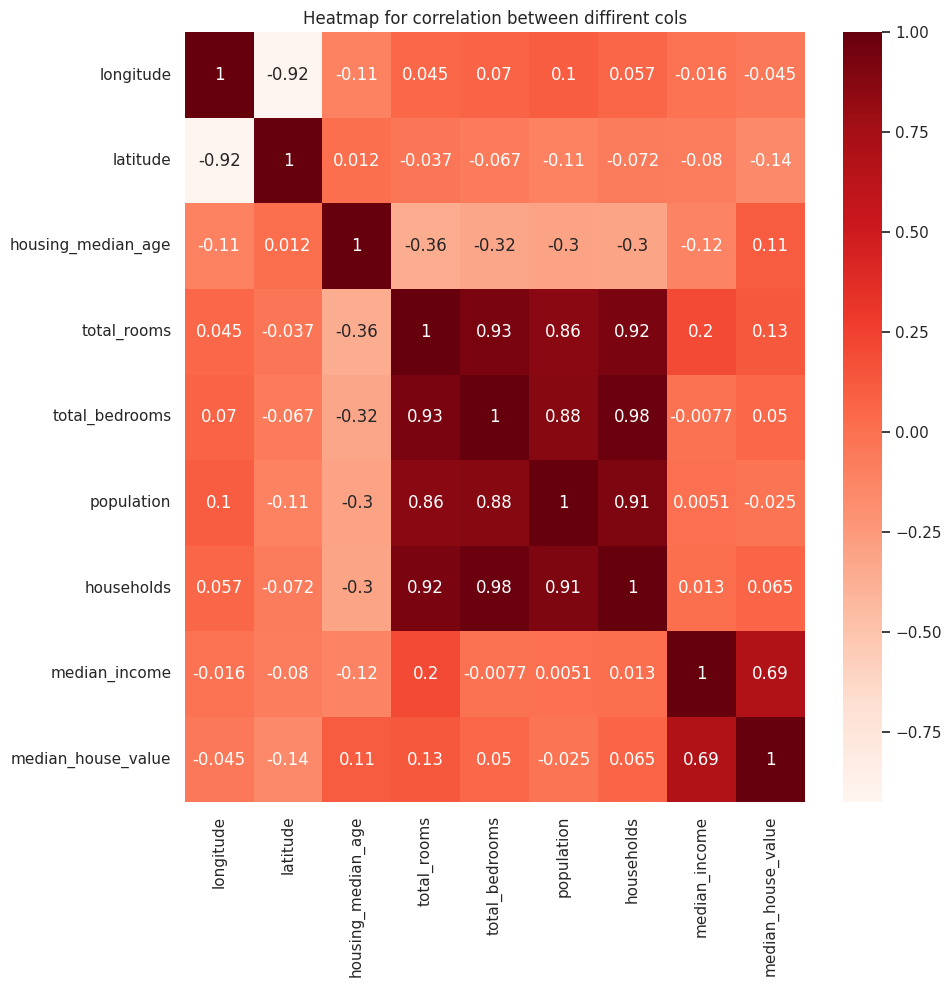

In [11]:
Hcali_df=cali_df[['longitude','latitude','housing_median_age','total_rooms','total_bedrooms','population','households','median_income','median_house_value']]

plt.figure(figsize=(10,10))
sns.set_theme(style='darkgrid')

graph_heatmap=sns.heatmap(Hcali_df.corr(),cmap='Reds',annot=True)

plt.title('Heatmap for correlation between diffirent cols')

plt.show()

In [12]:
def rmse(target,prediction):
    return np.sqrt(np.mean(np.square(target-prediction)))

In [13]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(cali_df[['ocean_proximity']])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['ocean_proximity']),index=cali_df.index)
cali_df = pd.concat([cali_df, encoded_df], axis=1)

In [14]:
cali_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0


### Linear Regression Model

In [15]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

input_col=['longitude','latitude','housing_median_age','total_rooms','total_bedrooms','population','households','median_income','ocean_proximity_<1H OCEAN','ocean_proximity_INLAND','ocean_proximity_ISLAND','ocean_proximity_NEAR BAY','ocean_proximity_NEAR OCEAN']

inputs=cali_df[input_col]
target=cali_df['median_house_value']

inputs_train,inputs_test,target_train,target_test=train_test_split(inputs,target,test_size=0.2,random_state=42)

In [16]:
model=LinearRegression().fit(inputs_train, target_train)

prediction_linear=model.predict(inputs_test)

mse = mean_squared_error(target_test, prediction_linear)
rmse = np.sqrt(mse)

print(f"RMSE: {rmse}")

RMSE: 69297.71669113015


### Random Forest Regressor Model

In [17]:
from sklearn.ensemble import RandomForestRegressor

model=RandomForestRegressor().fit(inputs_train,target_train)

prediction_Forest=model.predict(inputs_test)

mse = mean_squared_error(target_test, prediction_Forest)
rmse = np.sqrt(mse)

print(f"RMSE: {rmse}")

RMSE: 48922.47510177135
